### Using the HadISD datset (version 3.4.0.2023f) with PyEarthTools
HadISD is a global sub-daily dataset based on the ISD dataset from NOAA's NCEI. As well as station selection criteria, a suite of quality control tests has been run on the major climatological variables.

The dataset can be downloaded here: https://www.metoffice.gov.uk/hadobs/hadisd/v340_2023f/download.html

In [1]:
import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
import pyearthtools.tutorial


In [2]:
# train/validation/test split dates
train_start = "1970-01-01T00"
train_end = "2022-12-31T23"

In [ ]:
varname_val_map = {
        "total_cloud_cover": -888., 
        "low_cloud_cover": -888., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

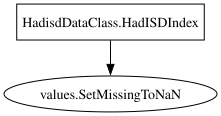

In [4]:
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(("010010-99999"), variables = ["total_cloud_cover", "temperatures"]),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    # petdata.transforms.variables.Drop(["station_id", "input_station_id"]),
    # petpipe.operations.xarray.conversion.ToNumpy(),
    # petdata.archive.hadisd("010014-99999", variables = ["slp", "dewpoints", "temperatures", "station_id"]),
    # petdata.archive.hadisd(country_code = "24", station_id = "010010", nearest_neighbors = 12, lon= 0.0, lat = 0.0), # Geospatial fence 
    # petdata.archive.hadisd("010014-99999"), # Geospatial fence
)
data_prep_pipe

In [5]:
ds = data_prep_pipe["1931-01-01T07"]
ds

/Users/joelmiller/Projects/Python/PyEarthTools_Fork/PyEarthTools/packages/data/src/pyearthtools/data/indexes/indexes.py:485: IndexWarning: Could not find time in dataset to select on. Petdt('1931-01-01T07')
  warnings.warn(


<xarray.Dataset> Size: 7MB
Dimensions:            (time: 276194)
Coordinates:
  * time               (time) datetime64[ns] 2MB 1931-01-01T06:00:00 ... 2023...
Data variables:
    temperatures       (time) float64 2MB dask.array<chunksize=(276194,), meta=np.ndarray>
    total_cloud_cover  (time) float64 2MB dask.array<chunksize=(276194,), meta=np.ndarray>
Attributes: (12/39)
    title:                       HadISD
    institution:                 Met Office Hadley Centre, Exeter, UK
    source:                      HadISD data product
    references:                  Dunn, 2019, Met Office Hadley Centre Technic...
    creator_name:                Robert Dunn
    creator_url:                 www.metoffice.gov.uk
    ...                          ...
    station_information:         Where station is a composite the station id ...
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    featureType:                 timeSeries
    processing_date:             08-Jan-2024
    history:                     Created by mk_netcdf_files.py \nDuplicate Mo...

In some cases you will get the following error when passing a date time to a pipeline object: `IndexWarning: Could not find time in dataset to select on. Petdt('1931-01-01T07')`<br>

This indicates that data for the datetime you chose does not exist. In this case PET will load all data from your station selection.

In [6]:
# show total_cloud_cover from ds
tcc = ds["total_cloud_cover"]
tcc

<xarray.DataArray 'total_cloud_cover' (time: 276194)> Size: 2MB
dask.array<where, shape=(276194,), dtype=float64, chunksize=(276194,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2MB 1931-01-01T06:00:00 ... 2023-12-31T23:...
Attributes:
    long_name:      Total cloud cover (oktas)
    units:          1
    flagged_value:  -888
    valid_min:      0
    valid_max:      8
    standard_name:  cloud_area_fraction
    cell_methods:   latitude: longitude: time: point (derived in priority ord...

In [ ]:
import xarray as xr
from pyearthtools.data.transforms.values import SetMissingToNaN
import numpy as np

def test_set_missing_to_nan():
    data = xr.Dataset({
        "total_cloud_cover": ("time", [0, -999, 50]),
        "low_cloud_cover": ("time", [10, -999, 20]),
    })

    varname_val_map = {
        "total_cloud_cover": -99.0,
        "low_cloud_cover": -999.0,
    }

    transform = SetMissingToNaN(varname_val_map)
    transformed_data = transform.apply(data)

    if np.isnan(transformed_data["total_cloud_cover"].data[1]):
        print("Total cloud cover at index 1 is NaN")
    else:
        print("Total cloud cover at index 1 is not NaN")
    
    if np.isnan(transformed_data["low_cloud_cover"].data[1]):
        print("Low cloud cover at index 1 is NaN")
    
    if transformed_data["total_cloud_cover"].data[2] == 50:
        print("Total cloud cover at index 2 is 50")

In [ ]:
test_set_missing_to_nan()